In [2]:
# Import the libraries

%pip install yfinance 
%pip install plotly
%pip install scikit-learn
%pip install xgboost
%pip install matplotlib
%pip install seaborn

import yfinance as yf

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go 
import plotly.express as px 
#import plotly.io as pio



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note

### Download the data from yfinanace

In [3]:
# Download the stock data from yfinance
import yfinance as yf
# Define the stock ticker and the date range
tickers = ['AAPL']
#tickers.append('GC=F')  # Gold futures
#tickers.append('BTC-USD')  # Bitcoin in USD
start_date = '2020-01-01'
end_date = '2026-01-01'

# Download the stock data
stocks = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
gold = yf.download('GC=F', start=start_date, end=end_date, auto_adjust=True)
BTC = yf.download('BTC-USD', start=start_date, end=end_date, auto_adjust=True)
sp500 = yf.download('^GSPC', start=start_date, end=end_date, auto_adjust=True)
nasdaq = yf.download('^IXIC', start=start_date, end=end_date, auto_adjust=True)
dowjones = yf.download('^DJI', start=start_date, end=end_date, auto_adjust=True)   

# Arrange the data so that 'Close' price can directly be used for plotting and calculations
stocks.columns = stocks.columns.droplevel(1)  # Drop the ticker level from columns
gold.columns = gold.columns.droplevel(1)
BTC.columns = BTC.columns.droplevel(1)
sp500.columns = sp500.columns.droplevel(1)
nasdaq.columns = nasdaq.columns.droplevel(1)
dowjones.columns = dowjones.columns.droplevel(1)

# Add the major indices as features to the stocks DataFrame
stocks['sp500'] = sp500['Close']
stocks['nasdaq'] = nasdaq['Close']
stocks['dowjones'] = dowjones['Close']

# reset the index to make 'Date' a column
#stocks.reset_index(inplace=True)
# Drop the Open, High, Low columns
stocks.drop(columns=['Open', 'High', 'Low'], inplace=True)

stocks.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,Volume,sp500,nasdaq,dowjones
Date,,,,,
2020-01-02,72.400520,135480400,3257.850098,9092.190430,28868.800781
2020-01-03,71.696648,146322800,3234.850098,9020.769531,28634.880859
2020-01-06,72.267944,118387200,3246.280029,9071.469727,28703.380859
2020-01-07,71.928040,108872000,3237.179932,9068.580078,28583.679688
2020-01-08,73.085091,132079200,3253.050049,9129.240234,28745.089844


In [4]:
# Normalize the gold and bitcoin prices to the first value to compare relative changes
def normalize_to_first(df):
    return df / df.iloc[0]

stocks['Gold'] = normalize_to_first(gold['Close'])
stocks['Bitcoin'] = normalize_to_first(BTC['Close'])


# Add the target variable, the direction of the stock price movement the next day
stocks['Target'] = np.where(stocks['Close'].shift(-1) > stocks['Close'], 1, 0)

# Add a target variable which predicts that at the end of next 5 days the stock price will be higher than today
#stocks['Target'] = np.where(stocks['Close'].shift(-5) > stocks['Close'], 1, 0)

stocks.head(20)

Price,Close,Volume,sp500,nasdaq,dowjones,Gold,Bitcoin,Target
Date,,,,,,,,
2020-01-02,72.400520,135480400,3257.850098,9092.190430,28868.800781,1.000000,0.970181,0
2020-01-03,71.696648,146322800,3234.850098,9020.769531,28634.880859,1.016202,1.020098,1
2020-01-06,72.267944,118387200,3246.280029,9071.469727,28703.380859,1.027353,1.079032,0
2020-01-07,71.928040,108872000,3237.179932,9068.580078,28583.679688,1.031027,1.133819,1
2020-01-08,73.085091,132079200,3253.050049,9129.240234,28745.089844,1.021581,1.122176,1
2020-01-09,74.637512,170108400,3274.699951,9203.429688,28956.900391,1.017842,1.094289,1
2020-01-10,74.806229,140644800,3265.350098,9178.860352,28823.769531,1.021646,1.134216,1
2020-01-13,76.404419,121532000,3288.129883,9273.929688,28907.050781,1.015677,1.131111,0
2020-01-14,75.372704,161954400,3283.149902,9251.330078,28939.669922,1.011742,1.226049,0


In [5]:
### Add Bollinger Bands to the stock data
# Calculate the 20-day moving average and standard deviation


def Bollinger_Bands(df, window=20, num_std_dev=2):
    df['MA20'] = df['Close'].rolling(window=window).mean()
    df['STD20'] = df['Close'].rolling(window=window).std()
    df['UpperBand'] = df['MA20'] + (df['STD20'] * num_std_dev)
    df['LowerBand'] = df['MA20'] - (df['STD20'] * num_std_dev)
    return df
stocks = Bollinger_Bands(stocks)  
#stocks.dropna(inplace=True)
#.reset_index(inplace=True)  # Drop rows with NaN values resulting from rolling calculations

stocks.head()

# Plot the stock price and Bollinger Bands
#pio.renderers.default = "browser"
def plot_bollinger_bands(stocks):
    fig = go.Figure().update_layout(width=1000, height=600, title='AAPL Stock Price with Bollinger Bands', xaxis_title='Date', yaxis_title='Price (USD)')
    fig.add_trace(go.Scatter(x=stocks.index, y=stocks['Close'], mode='lines', name='Close Price'))

    fig.add_trace(go.Scatter(x=stocks.index, 
                            y=stocks['UpperBand'], 
                            mode = 'lines', 
                            name='Upper Bollinger Band', 
                            line=dict(color='red', dash='dot')))

    fig.add_trace(go.Scatter(x=stocks.index, 
                            y=stocks['LowerBand'], 
                            mode = 'lines', 
                            name='Lower Bollinger Band', 
                            line=dict(color='red', dash='dot')))
    fig.show()
plot_bollinger_bands(stocks)


### Feature Engineering

In [6]:
print(stocks.index)

# Add a feature for return %
stocks['Return'] = stocks['Close'].pct_change()*100


# Add momentum and rate of change features
stocks['Momentum_5'] = stocks['Close'] - stocks['Close'].shift(5)
stocks['ROC_5'] = stocks['Close'].pct_change(5)*100

# Add return lags
def add_return_lags(df, lag_days=5):
    for lag in range(1, lag_days + 1):
        df[f'Return_Lag{lag}'] = df['Return'].shift(lag)
    return df
stocks = add_return_lags(stocks, lag_days=4)

# Get 5 day 20 day, 50 day, and 200 day moving averages for price
stocks['MA5'] = stocks['Close'].rolling(window=5).mean()
stocks['MA50'] = stocks['Close'].rolling(window=50).mean()
stocks['MA200'] = stocks['Close'].rolling(window=200).mean()

# Add a price vs moving average feature
stocks['Price_vs_MA20'] = stocks['Close']/stocks['MA5']

# Get the lag features for the closing price
def add_price_lags(df, lag_days=2):
    for lag in range(1, lag_days + 1):
        df[f'Lag{lag}'] = df['Close'].shift(lag)
    return df
stocks = add_price_lags(stocks, lag_days=6)

# Moving average of volume for last 5 days
stocks['Volume_MA5'] = stocks['Volume'].rolling(window=5).mean()

# Moving average of volume volatility for last 5 days
stocks['Volatility'] = stocks['Close'].rolling(window=5).std()

# Capture volume spikes
stocks['VolumeSpike'] = np.where(stocks['Volume'] > 
                                 (stocks['Volume'].rolling(window=20).mean() + 
                                  2*stocks['Volume'].rolling(window=20).std()), 1, 0)

print(stocks.index)

# Relative Strength Index (RSI)
def RSI(df, period=14):
    delta = df['Close'].diff()
    gains = delta.where(delta > 0, 0)
    losses = -delta.where(delta < 0, 0)
    avg_gains = gains.rolling(window=period).mean()
    avg_losses = losses.rolling(window=period).mean()
    rs = avg_gains/avg_losses
    #print(rs)
    df['RSI'] = 100 - (100/(1 + rs))
    return df

RSI(stocks, 14)

# MACD - Moving Average Convergence Divergence
def MACD(df, short_window=12, long_window=26, signal_window=9):
    df['EMA12'] = df['Close'].ewm(span=short_window).mean()
    df['EMA26'] = df['Close'].ewm(span=long_window).mean()
    df['MACD'] = df['EMA12'] - df['EMA26']
    df['SignalLine'] = df['MACD'].ewm(span=signal_window).mean()
    df['MACD_Histogram'] = df['MACD'] - df['SignalLine']
    return df

MACD(stocks)
###stocks.dropna(inplace=True)

# Add the seasonality features
stocks['DayOfWeek'] = stocks.index.dayofweek
stocks['Month'] = stocks.index.month
stocks['Quarter'] = stocks.index.quarter

stocks.head()


DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=1508, freq=None)
DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=1508, freq=None)


Price,Close,Volume,sp500,nasdaq,dowjones,Gold,Bitcoin,Target,MA20,STD20,...,VolumeSpike,RSI,EMA12,EMA26,MACD,SignalLine,MACD_Histogram,DayOfWeek,Month,Quarter
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.400520,135480400,3257.850098,9092.190430,28868.800781,1.000000,0.970181,0,NaN,NaN,...,0,NaN,72.400520,72.400520,0.000000,0.000000,0.000000,3,1,1
2020-01-03,71.696648,146322800,3234.850098,9020.769531,28634.880859,1.016202,1.020098,1,NaN,NaN,...,0,NaN,72.019256,72.035048,-0.015792,-0.008773,-0.007019,4,1,1
2020-01-06,72.267944,118387200,3246.280029,9071.469727,28703.380859,1.027353,1.079032,0,NaN,NaN,...,0,NaN,72.116319,72.118725,-0.002406,-0.006164,0.003758,0,1,1
2020-01-07,71.928040,108872000,3237.179932,9068.580078,28583.679688,1.031027,1.133819,1,NaN,NaN,...,0,NaN,72.056887,72.065418,-0.008531,-0.006966,-0.001565,1,1,1
2020-01-08,73.085091,132079200,3253.050049,9129.240234,28745.089844,1.021581,1.122176,1,NaN,NaN,...,0,NaN,72.336246,72.301884,0.034362,0.005328,0.029034,2,1,1


In [7]:
stocks[['Close', 'Return', 'Return_Lag1', 'Return_Lag2', 'Return_Lag3', 'Return_Lag4', 'Target']].head(20)

Price,Close,Return,Return_Lag1,Return_Lag2,Return_Lag3,Return_Lag4,Target
Date,,,,,,,
2020-01-02,72.400520,NaN,NaN,NaN,NaN,NaN,0
2020-01-03,71.696648,-0.972193,NaN,NaN,NaN,NaN,1
2020-01-06,72.267944,0.796825,-0.972193,NaN,NaN,NaN,0
2020-01-07,71.928040,-0.470340,0.796825,-0.972193,NaN,NaN,1
2020-01-08,73.085091,1.608623,-0.470340,0.796825,-0.972193,NaN,1
2020-01-09,74.637512,2.124129,1.608623,-0.470340,0.796825,-0.972193,1
2020-01-10,74.806229,0.226048,2.124129,1.608623,-0.470340,0.796825,1
2020-01-13,76.404419,2.136440,0.226048,2.124129,1.608623,-0.470340,0
2020-01-14,75.372704,-1.350335,2.136440,0.226048,2.124129,1.608623,0


In [ ]:
print(stocks.index)
def plot_stock_feature(stocks, feature_name):
    fig = go.Figure().update_layout(width=1000, height=600, title=f'AAPL Stock {feature_name}', xaxis_title='Date', yaxis_title='Price (USD)')
    fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature_name], mode='lines', name=feature_name))
    fig.show()

def plot_overlay(stocks, feature1, feature2, feature3=None, feature4=None, title=None):
    fig = go.Figure().update_layout(width=1000, height=600, title=title or f'AAPL Stock {feature1} vs {feature2}', xaxis_title='Date', yaxis_title='Value')
    fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature1], mode='lines', name=feature1, line=dict(color='blue')))
    fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature2], mode='lines', name=feature2, line=dict(color='red')))
    if feature3 is not None:
        fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature3], mode='lines', name=feature3, line=dict(color='green')))
    if feature4 is not None:
        fig.add_trace(go.Scatter(x=stocks.index, y=stocks[feature4], mode='lines', name=feature4, line=dict(color='orange')))
    fig.show()

plot_stock_feature(stocks, 'Return')
#plot_stock_feature(stocks, 'Momentum_5')
plot_stock_feature(stocks, 'ROC_5')
plot_overlay(stocks, 'Close', 'MA5', 'MA50', 'MA200', title='AAPL Stock Price vs Momentum indicators')

#plot_overlay(stocks, 'Close', 'Return', 'Momentum_5', 'ROC_5', title='AAPL Stock Price vs Momentum indicators')

def plot_log_indicators(stocks):
    # Add log of momentum features
    stocks['LogReturn'] = np.log2(stocks['Return'] + 100)  # Shift to avoid log of negative numbers
    stocks['LogMomentum_5'] = np.log2(stocks['Momentum_5'] + 100)  # Shift to avoid log of negative numbers
    stocks['LogROC_5'] = np.log2(stocks['ROC_5'] + 100)  # Shift to avoid log of negative numbers
    stocks['LogClose'] = np.log2(stocks['Close'])  # Log of closing price for better visualization
    plot_overlay(stocks, 'LogClose', 'LogReturn', 'LogMomentum_5', 'LogROC_5', title='AAPL Stock Price vs Momentum indicators')



DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[s]', name='Date', length=1508, freq=None)


In [ ]:
# More useful plot to understand the data
stocks.dropna()
stocks['RSI_bin'] = pd.cut(stocks['RSI'], bins=5, labels=False)
#stocks.groupby('RSI_bin')['Target'].mean()
stocks.head()

# Plot the Stock Return distribution
fig = px.histogram(stocks, x='Return', nbins=50, title='Distribution of AAPL Stock Returns', labels={'Return': 'Daily Return (%)'})
fig.update_layout(width=1000, height=600)  
fig.show()

# Target variable distribution
fig = px.histogram(stocks, x='Target', title='Distribution of Target Variable (Stock Price Direction)', labels={'Target': 'Stock Direction (0=Down, 1=Up)'})
fig.update_layout(width=1000, height=600)
fig.show()
stocks['Target'].value_counts(normalize=True)*100




Target
1    53.116711
0    46.883289
Name: proportion, dtype: float64

Correlation of features with Target variable:
Price
Target            1.000000
Quarter           0.028937
Month             0.027565
Bitcoin           0.026347
Gold              0.025415
sp500             0.020795
MA200             0.019822
nasdaq            0.018557
Return            0.016747
dowjones          0.016192
MA50              0.013406
EMA26             0.008741
UpperBand         0.008307
Lag5              0.008200
MA20              0.008088
Lag6              0.007772
LowerBand         0.007753
EMA12             0.005757
STD20             0.005408
Volatility        0.004919
Lag4              0.004697
Close             0.003698
MA5               0.003128
Lag3              0.003005
Lag2              0.002759
Lag1              0.001448
Return_Lag2      -0.003151
Price_vs_MA20    -0.007146
RSI              -0.007406
DayOfWeek        -0.009091
RSI_bin          -0.012861
VolumeSpike      -0.014811
MACD_Histogram   -0.018315
Volume_MA5       -0.019318
Volume           -0.020357
Ret

<Axes: title={'center': 'Correlation of Lag Features with Target Variable'}, ylabel='Price'>

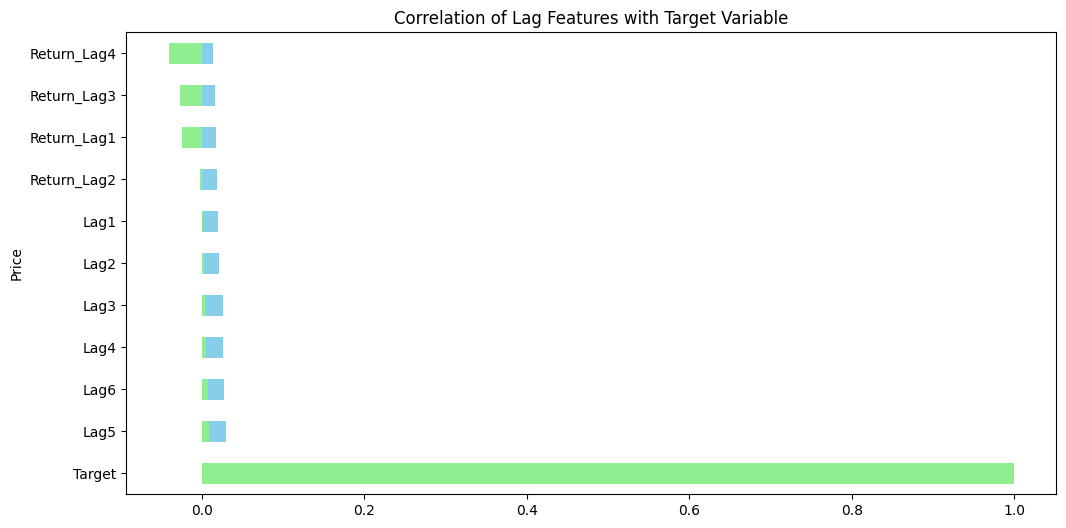

In [ ]:
# Check feature correations with the target variable
corr_with_target = stocks.corr()['Target'].sort_values(ascending=False)
print("Correlation of features with Target variable:")
print(corr_with_target)
stocks.corr()
corr_with_target.plot(kind='barh', title='Correlation of Features with Target Variable', figsize=(12, 10), color='skyblue')
print(corr_with_target)
#fig = px.imshow(stocks.corr(), title='Correlation Heatmap of Stock Features', width=1000, height=800)
fig.show()

#corr_with_close = stocks.corr()['Close'].sort_values(ascending=False).drop('Close')
#print("Correlation of features with Close price:")
#print(corr_with_close)
#corr_with_close.plot(kind='barh', title='Correlation of Features with Close Price', figsize=(12, 6), color='salmon')
#fig.show()

# Correlation of lag features with the target variable
lag_features = [col for col in stocks.columns if 'Lag' in col]
corr_with_lags = stocks[lag_features + ['Target']].corr()['Target'].sort_values(ascending=False)
corr_with_lags.plot(kind='barh', title='Correlation of Lag Features with Target Variable', figsize=(12, 6), color='lightgreen')

0.5753580311872392
[0.07592484 0.93154763 0.92939091 ... 0.07592484 0.07829721 0.06517293]
Price         rmean3  Target   prob_up buy_sell
Date                                           
2024-11-18  0.666667       1  0.929391      Buy
2024-11-19  1.000000       1  0.941309      Buy
2024-11-20  0.666667       0  0.091004     Sell
2024-11-21  0.666667       1  0.931548      Buy
2024-11-22  0.666667       1  0.929391      Buy
2024-11-25  1.000000       1  0.941309      Buy
2024-11-26  0.666667       0  0.091004     Sell
2024-11-27  0.666667       1  0.931548      Buy
2024-11-29  0.666667       1  0.929391      Buy
2024-12-02  1.000000       1  0.941309      Buy
2024-12-03  1.000000       1  0.941309      Buy
2024-12-04  1.000000       1  0.941309      Buy
2024-12-05  0.666667       0  0.091004     Sell
2024-12-06  0.666667       1  0.931548      Buy
2024-12-09  0.666667       1  0.929391      Buy
2024-12-10  0.666667       0  0.091004     Sell
2024-12-11  0.666667       1  0.931548      B

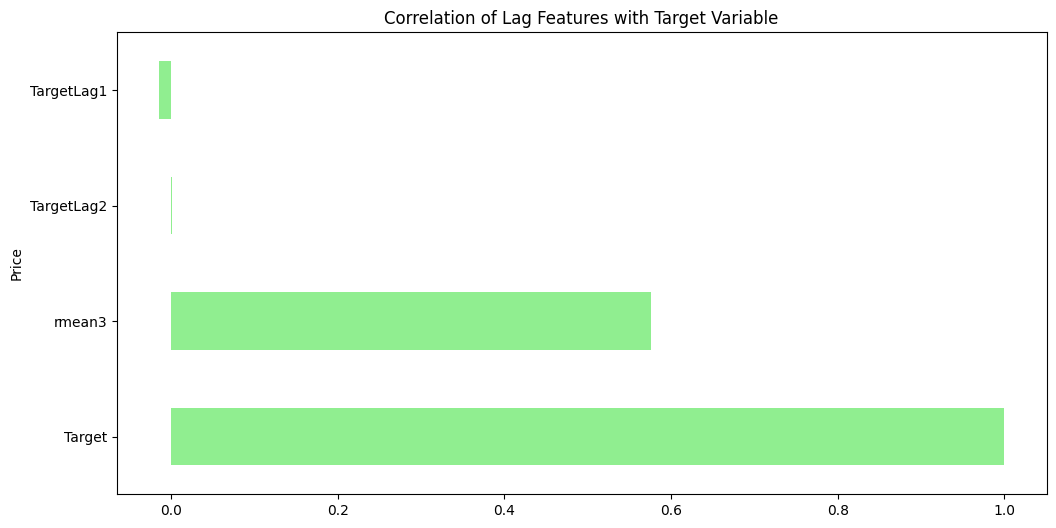

In [54]:
stocks['TargetLag1'] = stocks['Target'].shift(1)
stocks['TargetLag2'] = stocks['Target'].shift(2)
stocks['rmean3'] = stocks['Target'].rolling(window=3).mean()
stocks['rmean5'] = stocks['Target'].rolling(window=5).mean()
stocks['rmean20'] = stocks['Target'].rolling(window=20).mean()

#lags = stocks.loc[(stocks.index > '2024-11-15') & (stocks.index < '2024-12-31')][['TargetLag1', 'TargetLag2', 'Target']]
lags = stocks[['TargetLag1', 'TargetLag2', 'rmean3', 'Target']].dropna()

print(stocks['rmean3'].corr(stocks['Target']))

corr_with_lags = lags.corr()['Target'].sort_values(ascending=False)
corr_with_lags.plot(kind='barh', title='Correlation of Lag Features with Target Variable', figsize=(12, 6), color='lightgreen')
#print(lags.head(25))

#print(stocks['Target'].groupby(stocks['TargetLag1']).mean())
stocks.groupby("TargetLag1")["Target"].mean()

# Logistic Regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = lags.drop(columns=['Target'])
lr = LogisticRegression(max_iter=1000).fit(X, y=lags['Target'])
probs = lr.predict_proba(X)[:, 1]  # Probability of the positive class (stock going up)
print(probs)
lags['prob_up'] = probs

lags['buy_sell'] = np.where(lags['prob_up'] > 0.6, 'Buy', 'Sell')
print(lags.loc[(lags.index > '2024-11-15') & (lags.index < '2024-12-31')].drop(columns=['TargetLag1', 'TargetLag2']).head(20))


from sklearn.metrics import classification_report
#print(classification_report(lags['Target'], lr.predict(X)))
#print(lags.head(20 ))
#print(probs) 

In [ ]:


# Scatter plot of momentum indicators vs stock target
#fig = px.scatter(stocks, x='RSI', y='Target', title='Momentum Indicator vs Stock Target', width=1000, height=600)
#fig.show()

#import seaborn as sns
#sns.boxplot(x=stocks['Target'], y=stocks['RSI'])


(stocks['RSI'] > 70).groupby(stocks['Target']).mean()
#(stocks['RSI'] < 30).groupby(stocks['Target']).mean()

Target
0    0.207921
1    0.183521
Name: RSI, dtype: float64

In [ ]:
# Drop rows with NaN values resulting from rolling calculations
stocks.dropna(inplace=True)

def drop_columns_and_reset_index(df, columns_to_drop):
    df.drop(columns=columns_to_drop, inplace=True)
    df.reset_index(inplace=True)
    return df
# Remove the date column as it won't be used for modeling
#stocks.reset_index(inplace=True)
# Remove the features that won't be used for modeling
#stocks = drop_columns_and_reset_index(stocks, ['Date', 'EMA12', 'EMA26', 'STD20', 'SignalLine'])
#stocks.drop(columns=['price'], inplace=True)

stocks.head()

Price,Close,Volume,sp500,nasdaq,dowjones,Gold,Bitcoin,Target,MA20,STD20,...,RSI,EMA12,EMA26,MACD,SignalLine,MACD_Histogram,DayOfWeek,Month,Quarter,RSI_bin
Date,,,,,,,,,,,,,,,,,,,,,
2020-10-15,117.193382,112559200,3483.340088,11713.870117,28494.199219,1.248409,1.596538,0,111.411873,4.617884,...,63.102253,114.616186,112.971436,1.644749,0.772488,0.872262,3,10,4,3.0
2020-10-16,115.552628,115393800,3483.810059,11671.559570,28606.310547,1.246835,1.572479,0,112.003131,4.330287,...,56.510584,114.760254,113.162636,1.597618,0.937514,0.660104,4,10,4,2.0
2020-10-19,112.601166,120639300,3426.919922,11478.879883,28195.419922,1.250508,1.630799,1,112.289535,4.159175,...,52.833528,114.428086,113.121045,1.307041,1.011419,0.295622,0,10,4,2.0
2020-10-20,114.086624,124423700,3443.120117,11516.490234,28308.789062,1.253132,1.655006,0,112.566232,4.080829,...,52.563332,114.375554,113.192570,1.182984,1.045732,0.137252,1,10,4,2.0
2020-10-21,113.465240,89946000,3435.560059,11484.690430,28210.820312,1.262447,1.781025,0,113.039529,3.549246,...,50.121837,114.235506,113.212767,1.022738,1.041133,-0.018395,2,10,4,2.0


# Modeling - using Logistical Regression

In [ ]:
# Test train split

def test_train_split_local(df, target_col='Target', test_size=0.2):
    X = df.drop(columns=[target_col, 'Date'])
    y = df[target_col]
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
    return X_train, X_test, y_train, y_test


def run_logistic_regression(stocks):
    from sklearn.linear_model import LogisticRegression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)
    lr.fit(X_train, y_train)

    score = lr.score(X_test, y_test)

    print(f"Logistic Regression Accuracy: {score:.2f}")


## Using other classification models like RandomForest, KNN

In [ ]:
def run_random_forest(stocks):
    from sklearn.ensemble import RandomForestClassifier
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    rf.fit(X_train, y_train)    

    score = rf.score(X_test, y_test)
    print(f"Random Forest Accuracy: {score:.2f}")

In [ ]:
# KNN
def run_knn(stocks):
    from sklearn.neighbors import KNeighborsClassifier
    knn = KNeighborsClassifier(n_neighbors=5)
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    knn.fit(X_train, y_train)

    score = knn.score(X_test, y_test)
    print(f"KNN Accuracy: {score:.2f}")


### Choose the Model hyperparameters using GridSearchCV

In [ ]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1],
    'fit_intercept': [True, False]
}

grid_search = GridSearchCV(lr, param_grid)
grid_search.fit(X_train, y_train)
print(f"Best Hyperparameters: {grid_search.best_params_}")

NameError: name 'lr' is not defined

### Using models with updated parameters

In [ ]:
def run_tuned_logistic_regression(stocks, grid_search):
    X_train, X_test, y_train, y_test = test_train_split_local(stocks, target_col='Target', test_size=0.2)

    lr_tuned = LogisticRegression(C=grid_search.best_params_['C'], 
        fit_intercept=grid_search.best_params_['fit_intercept'], max_iter=1000, random_state=42)
    lr_tuned.fit(X_train, y_train)
    score = lr_tuned.score(X_test, y_test)
    print(f"Tuned Logistic Regression Accuracy: {score:.2f}")

In [ ]:
stocks.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 42 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   Date            1309 non-null   datetime64[s]
 1   Close           1309 non-null   float64      
 2   Volume          1309 non-null   int64        
 3   sp500           1309 non-null   float64      
 4   nasdaq          1309 non-null   float64      
 5   dowjones        1309 non-null   float64      
 6   Gold            1309 non-null   float64      
 7   Bitcoin         1309 non-null   float64      
 8   Target          1309 non-null   int64        
 9   MA20            1309 non-null   float64      
 10  STD20           1309 non-null   float64      
 11  UpperBand       1309 non-null   float64      
 12  LowerBand       1309 non-null   float64      
 13  Return          1309 non-null   float64      
 14  Momentum_5      1309 non-null   float64      
 15  ROC_5           1309 non-null   

In [ ]:
# Remove more features and see if it improves accuracy
#stocks.drop(columns=['index', 'sp500', 'VolumeSpike'], inplace=True)
stocks_cpy = stocks.copy()
stocks_cpy = drop_columns_and_reset_index(stocks_cpy, ['EMA12', 'EMA26', 'STD20', 'SignalLine', 'Return_Lag1', 'Return_Lag2'])
stocks_cpy.info()


<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 37 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   index           1309 non-null   int64        
 1   Date            1309 non-null   datetime64[s]
 2   Close           1309 non-null   float64      
 3   Volume          1309 non-null   int64        
 4   sp500           1309 non-null   float64      
 5   nasdaq          1309 non-null   float64      
 6   dowjones        1309 non-null   float64      
 7   Gold            1309 non-null   float64      
 8   Bitcoin         1309 non-null   float64      
 9   Target          1309 non-null   int64        
 10  MA20            1309 non-null   float64      
 11  UpperBand       1309 non-null   float64      
 12  LowerBand       1309 non-null   float64      
 13  Return          1309 non-null   float64      
 14  Momentum_5      1309 non-null   float64      
 15  ROC_5           1309 non-null   

In [ ]:
# Using XG boost
def run_xgboost(stocks):
    from xgboost import XGBClassifier
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb.fit(X_train, y_train)   
    score = xgb.score(X_test, y_test)
    print(f"XGBoost Accuracy: {score:.2f}")

### Check the importance of different features

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = test_train_split_local(stocks_cpy, target_col='Target', test_size=0.2)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print('Random Forest Accuracy: {:.2f}'.format(rf.score(X_test, y_test)))

# print the name of the feature along with its importance
for feature, importance in zip(X_train.columns, rf.feature_importances_):
    print(f'{feature}: {importance:.4f}')

Random Forest Accuracy: 0.52
index: 0.0264
Close: 0.0293
Volume: 0.0375
sp500: 0.0296
nasdaq: 0.0278
dowjones: 0.0300
Gold: 0.0360
Bitcoin: 0.0269
MA20: 0.0237
UpperBand: 0.0264
LowerBand: 0.0253
Return: 0.0417
Momentum_5: 0.0367
ROC_5: 0.0356
Return_Lag3: 0.0379
Return_Lag4: 0.0405
MA5: 0.0240
MA50: 0.0252
MA200: 0.0280
Price_vs_MA20: 0.0372
Lag1: 0.0269
Lag2: 0.0282
Lag3: 0.0257
Lag4: 0.0225
Lag5: 0.0245
Lag6: 0.0289
Volume_MA5: 0.0444
Volatility: 0.0327
VolumeSpike: 0.0024
RSI: 0.0373
MACD: 0.0330
MACD_Histogram: 0.0342
DayOfWeek: 0.0172
Month: 0.0114
Quarter: 0.0050


In [ ]:
def AddFEDFeatures(stocks, start_date, end_date):
    # Use the FED data to get the following features:
    # - Federal Funds Rate
    # - Inflation Rate
    # - Unemployment Rate
    %pip install fredapi
    from fredapi import Fred
    fred = Fred(api_key='c06a7676bffb4c8338823496ee6287bf')

    interest_rate = fred.get_series('FEDFUNDS', observation_start=start_date, observation_end=end_date)
    inflation_rate = fred.get_series('CPIAUCSL', observation_start=start_date, observation_end=end_date)
    unemployment_rate = fred.get_series('UNRATE', observation_start=start_date, observation_end=end_date)

    print(interest_rate.head())

    stocks['FederalFundsRate'] = interest_rate
    stocks['InflationRate'] = inflation_rate
    stocks['UnemploymentRate'] = unemployment_rate

